CH.SC.U4CSE24111-DARUNKUMAR J

Decision Tree Classifier Exercise-1

Saving decision_tree_exercise1_dataset.csv to decision_tree_exercise1_dataset.csv
Dataset:
    Age  Income  Buy_House
0    25   25000          0
1    30   30000          0
2    35   40000          0
3    40   50000          1
4    45   60000          1
5    50   70000          1
6    55   80000          1
7    60   90000          1
8    28   28000          0
9    32   35000          0
10   38   45000          1
11   42   55000          1
12   48   65000          1
13   52   75000          1
14   58   85000          1
15   65   95000          1
16   23   22000          0
17   27   27000          0
18   36   42000          1
19   46   62000          1

Null Values:
Age          0
Income       0
Buy_House    0
dtype: int64

Training Data Shape: (14, 2)
Testing Data Shape: (6, 2)

Predicted Values:
[1 1 0 1 1 0]

Confusion Matrix:
[[2 1]
 [0 3]]

Accuracy Score: 0.8333333333333334
Accuracy in Percentage: 83.33333333333334 %

Classification Report:
              precision    recall  f1-scor

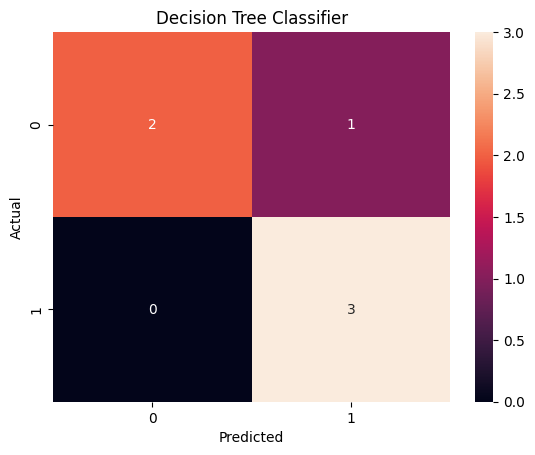


New Person:
Age: 45
Income: 65000
Prediction: The person is likely to buy a house.


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
import seaborn as sn
import matplotlib.pyplot as plt

from google.colab import files

uploaded = files.upload()

# Read the dataset
data = pd.read_csv("decision_tree_exercise1_dataset.csv")

print("Dataset:")
print(data)

# Check for null values
print("\nNull Values:")
print(data.isnull().sum())

# Independent and dependent variables
X = data[["Age", "Income"]]
y = data["Buy_House"]

# 70% Training and 30% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=5
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

# Create Decision Tree Classifier
model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=5
)

# Train the model
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("\nPredicted Values:")
print(y_pred)

# Confusion Matrix
conf_mat = metrics.confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(conf_mat)

# Accuracy
accuracy = metrics.accuracy_score(y_test, y_pred)

print("\nAccuracy Score:", accuracy)
print("Accuracy in Percentage:", accuracy * 100, "%")

# Classification Report
print("\nClassification Report:")
print(metrics.classification_report(y_test, y_pred))

# Confusion Matrix Visualization
conf_mat = pd.crosstab(
    y_test,
    y_pred,
    rownames=["Actual"],
    colnames=["Predicted"]
)

sn.heatmap(conf_mat, annot=True, fmt="d")
plt.title("Decision Tree Classifier")
plt.show()

# Predict a new person
new_person = [[45, 65000]]

prediction = model.predict(new_person)

print("\nNew Person:")
print("Age:", new_person[0][0])
print("Income:", new_person[0][1])

if prediction[0] == 1:
    print("Prediction: The person is likely to buy a house.")
else:
    print("Prediction: The person is not likely to buy a house.")